# Solving Laplace's Equation: Numerical Methods vs. Physics-Informed Neural Networks

This notebook solves the **2D Laplace equation** using two fundamentally different approaches:

1. **Numerical Method** — Finite Difference Method (FDM) with a direct sparse solver
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

At the end, we compare both solutions side by side.

---

## Problem Statement

Laplace's equation in 2D:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0, \quad (x, y) \in [0, 1]^2$$

**Boundary conditions:**

| Edge | Condition |
|------|-----------|
| Bottom: $y = 0$ | $u(x, 0) = \sin(\pi x)$ |
| Top: $y = 1$ | $u(x, 1) = 0$ |
| Left: $x = 0$ | $u(0, y) = 0$ |
| Right: $x = 1$ | $u(1, y) = 0$ |

**Analytical solution** (for reference):

$$u(x, y) = \frac{\sin(\pi x) \cdot \sinh(\pi (1 - y))}{\sinh(\pi)}$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Color map used throughout
CMAP = "inferno"

---

## Part 1 — Numerical Method: Finite Difference Method (FDM)

### How It Works

We discretize the domain into an $N \times N$ grid with spacing $h = \frac{1}{N-1}$.

At each interior node $(i, j)$, we apply the standard **5-point stencil**:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h^2} + \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{h^2} = 0$$

which simplifies to:

$$u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j} = 0$$

This turns into a **sparse linear system $Au = b$** that we solve directly.

Boundary nodes are handled by fixing their values in the system.


In [ ]:
def solve_laplace_fdm(N=64):
    """
    Solves Laplace's equation on [0,1]^2 using the Finite Difference Method.
    Assembles a sparse linear system and solves it directly.

    Parameters
    ----------
    N : int
        Number of grid points along each axis (grid size N x N).

    Returns
    -------
    X, Y : ndarray of shape (N, N)
        Meshgrid of coordinates.
    U : ndarray of shape (N, N)
        Solution values on the grid.
    """
    h = 1.0 / (N - 1)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y)

    # Total unknowns: N*N (includes boundary nodes)
    n_unknowns = N * N

    def idx(i, j):
        """Flatten 2D grid index (row i, col j) to 1D."""
        return i * N + j

    A = lil_matrix((n_unknowns, n_unknowns))
    b = np.zeros(n_unknowns)

    for i in range(N):       # row index  -> y direction
        for j in range(N):   # col index  -> x direction
            k = idx(i, j)
            xi = x[j]
            yi = y[i]

            # ---- Boundary nodes: set u = known value ----
            is_boundary = (i == 0) or (i == N - 1) or (j == 0) or (j == N - 1)
            if is_boundary:
                A[k, k] = 1.0
                # Bottom edge: y = 0  (i == 0)
                if i == 0:
                    b[k] = np.sin(np.pi * xi)
                # All other boundaries: u = 0
                else:
                    b[k] = 0.0
            else:
                # ---- Interior nodes: 5-point stencil ----
                A[k, idx(i,     j    )] = -4.0
                A[k, idx(i + 1, j    )] =  1.0
                A[k, idx(i - 1, j    )] =  1.0
                A[k, idx(i,     j + 1)] =  1.0
                A[k, idx(i,     j - 1)] =  1.0
                b[k] = 0.0

    # Solve the sparse system
    A_csr = A.tocsr()
    u_flat = spsolve(A_csr, b)
    U = u_flat.reshape(N, N)

    return X, Y, U


N_FDM = 64
X_fdm, Y_fdm, U_fdm = solve_laplace_fdm(N=N_FDM)
print(f"FDM solved on a {N_FDM}x{N_FDM} grid ({N_FDM**2} unknowns).")
print(f"Solution range: [{U_fdm.min():.4f}, {U_fdm.max():.4f}]")

FDM solved on a 64x64 grid (4096 unknowns).
Solution range: [0.0000, 0.9997]


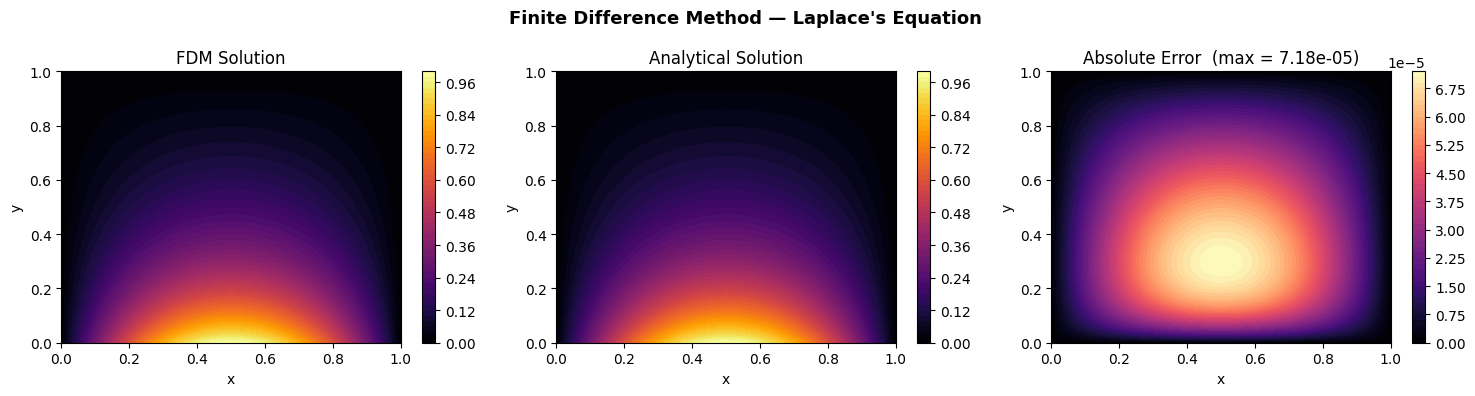

FDM — Max absolute error: 7.18e-05  |  Mean absolute error: 2.71e-05


In [3]:
def analytical_solution(X, Y):
    """Exact solution: u(x,y) = sin(πx) * sinh(π(1-y)) / sinh(π)."""
    return np.sin(np.pi * X) * np.sinh(np.pi * (1 - Y)) / np.sinh(np.pi)


U_exact_fdm = analytical_solution(X_fdm, Y_fdm)
fdm_error = np.abs(U_fdm - U_exact_fdm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].contourf(X_fdm, Y_fdm, U_fdm, levels=50, cmap=CMAP)
axes[0].set_title("FDM Solution")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_fdm, Y_fdm, U_exact_fdm, levels=50, cmap=CMAP)
axes[1].set_title("Analytical Solution")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_fdm, Y_fdm, fdm_error, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error  (max = {fdm_error.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Finite Difference Method — Laplace's Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"FDM — Max absolute error: {fdm_error.max():.2e}  |  Mean absolute error: {fdm_error.mean():.2e}")

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### How It Works

A PINN replaces the grid with a neural network $\hat{u}_\theta(x, y)$ trained to satisfy **both** the PDE and the boundary conditions simultaneously.

**Loss function:**

$$\mathcal{L} = \underbrace{\mathcal{L}_{BC}}_{\text{boundary loss}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics loss}}$$

$$\mathcal{L}_{BC} = \frac{1}{N_b}\sum_{k} \left(\hat{u}(x_k^b, y_k^b) - u_k^b\right)^2$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_{k} \left(\frac{\partial^2 \hat{u}}{\partial x^2}\bigg|_{(x_k^f, y_k^f)} + \frac{\partial^2 \hat{u}}{\partial y^2}\bigg|_{(x_k^f, y_k^f)}\right)^2$$

The derivatives are computed via **automatic differentiation** (`torch.autograd`), so no explicit finite-difference stencil is needed.

**Key design choices:**
- `Tanh` activations (smooth, infinitely differentiable — required for second-order derivatives)
- Adam optimiser followed by L-BFGS fine-tuning for fast, accurate convergence


In [4]:
# ----------------------------------------------------------
# Network Architecture
# ----------------------------------------------------------
class PINN(nn.Module):
    """Fully-connected network: (x, y) → u.

    Uses Tanh activations because the PDE involves second-order
    derivatives; Tanh is smooth everywhere so autograd can
    differentiate through it twice without collapsing to zero.
    """
    def __init__(self, hidden_layers=4, hidden_dim=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


def grad(output, input_):
    """First-order derivative via autograd (keeps graph for higher orders)."""
    return torch.autograd.grad(
        output, input_,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True,
    )[0]


# ----------------------------------------------------------
# Collocation and Boundary Points
# ----------------------------------------------------------
N_BOUNDARY = 200   # points per edge
N_INTERIOR = 5000  # interior (physics) points

def make_boundary_points(n):
    """Returns (x, y, u_target) tensors for all four edges."""
    t = torch.rand(n, 1)

    # Bottom: y=0, u = sin(πx)
    x_b = t.clone().requires_grad_(False)
    y_b = torch.zeros_like(x_b)
    u_b = torch.sin(torch.pi * x_b)

    # Top: y=1, u = 0
    x_t = t.clone().requires_grad_(False)
    y_t = torch.ones_like(x_t)
    u_t = torch.zeros_like(x_t)

    # Left: x=0, u = 0
    x_l = torch.zeros(n, 1)
    y_l = t.clone().requires_grad_(False)
    u_l = torch.zeros_like(x_l)

    # Right: x=1, u = 0
    x_r = torch.ones(n, 1)
    y_r = t.clone().requires_grad_(False)
    u_r = torch.zeros_like(x_r)

    x_bc = torch.cat([x_b, x_t, x_l, x_r])
    y_bc = torch.cat([y_b, y_t, y_l, y_r])
    u_bc = torch.cat([u_b, u_t, u_l, u_r])
    return x_bc, y_bc, u_bc


x_bc, y_bc, u_bc = make_boundary_points(N_BOUNDARY)

x_int = torch.rand(N_INTERIOR, 1, requires_grad=True)
y_int = torch.rand(N_INTERIOR, 1, requires_grad=True)

print(f"Boundary points : {x_bc.shape[0]}")
print(f"Interior points : {x_int.shape[0]}")

Boundary points : 800
Interior points : 5000


In [5]:
# ----------------------------------------------------------
# Loss Function
# ----------------------------------------------------------
mse = nn.MSELoss()

def compute_loss(model, x_int, y_int, x_bc, y_bc, u_bc):
    # Boundary loss
    u_pred_bc = model(x_bc, y_bc)
    loss_bc = mse(u_pred_bc, u_bc)

    # Physics loss: u_xx + u_yy = 0
    u_pred = model(x_int, y_int)
    u_x  = grad(u_pred, x_int)
    u_y  = grad(u_pred, y_int)
    u_xx = grad(u_x,    x_int)
    u_yy = grad(u_y,    y_int)
    residual = u_xx + u_yy
    loss_pde = mse(residual, torch.zeros_like(residual))

    return loss_bc + loss_pde, loss_bc, loss_pde


# ----------------------------------------------------------
# Phase 1 — Adam optimiser
# ----------------------------------------------------------
model = PINN(hidden_layers=4, hidden_dim=64)
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

ADAM_EPOCHS = 3000
history = []

for epoch in range(1, ADAM_EPOCHS + 1):
    optimizer_adam.zero_grad()
    loss, l_bc, l_pde = compute_loss(model, x_int, y_int, x_bc, y_bc, u_bc)
    loss.backward()
    optimizer_adam.step()
    history.append(loss.item())

    if epoch % 500 == 0:
        print(f"[Adam] Epoch {epoch:5d} | Loss {loss.item():.5f} | BC {l_bc.item():.5f} | PDE {l_pde.item():.5f}")

print("Adam phase done.")

[Adam] Epoch   500 | Loss 0.01828 | BC 0.01679 | PDE 0.00150
[Adam] Epoch  1000 | Loss 0.00984 | BC 0.00887 | PDE 0.00097
[Adam] Epoch  1500 | Loss 0.00595 | BC 0.00479 | PDE 0.00116
[Adam] Epoch  2000 | Loss 0.00413 | BC 0.00337 | PDE 0.00077
[Adam] Epoch  2500 | Loss 0.00228 | BC 0.00167 | PDE 0.00061
[Adam] Epoch  3000 | Loss 0.00153 | BC 0.00114 | PDE 0.00039
Adam phase done.


In [6]:
# ----------------------------------------------------------
# Phase 2 — L-BFGS fine-tuning
# ----------------------------------------------------------
optimizer_lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=50,
    line_search_fn="strong_wolfe",
)

def closure():
    optimizer_lbfgs.zero_grad()
    loss, _, _ = compute_loss(model, x_int, y_int, x_bc, y_bc, u_bc)
    loss.backward()
    history.append(loss.item())
    return loss

optimizer_lbfgs.step(closure)

final_loss, _, _ = compute_loss(model, x_int, y_int, x_bc, y_bc, u_bc)
print(f"L-BFGS done. Final loss: {final_loss.item():.6f}")

L-BFGS done. Final loss: 0.000019


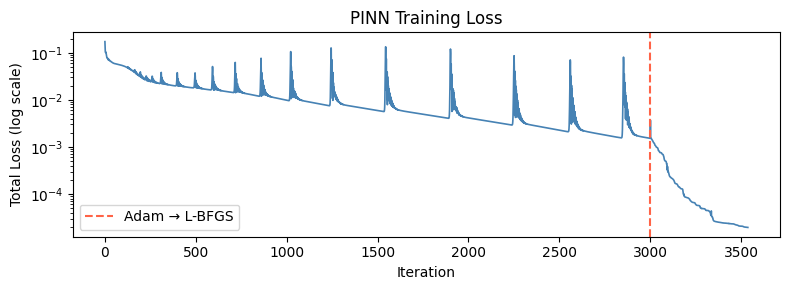

In [7]:
# ----------------------------------------------------------
# Training Loss Curve
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history, color="steelblue", linewidth=1.2)
ax.axvline(x=ADAM_EPOCHS, color="tomato", linestyle="--", label="Adam → L-BFGS")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total Loss (log scale)")
ax.set_title("PINN Training Loss")
ax.legend()
plt.tight_layout()
plt.show()

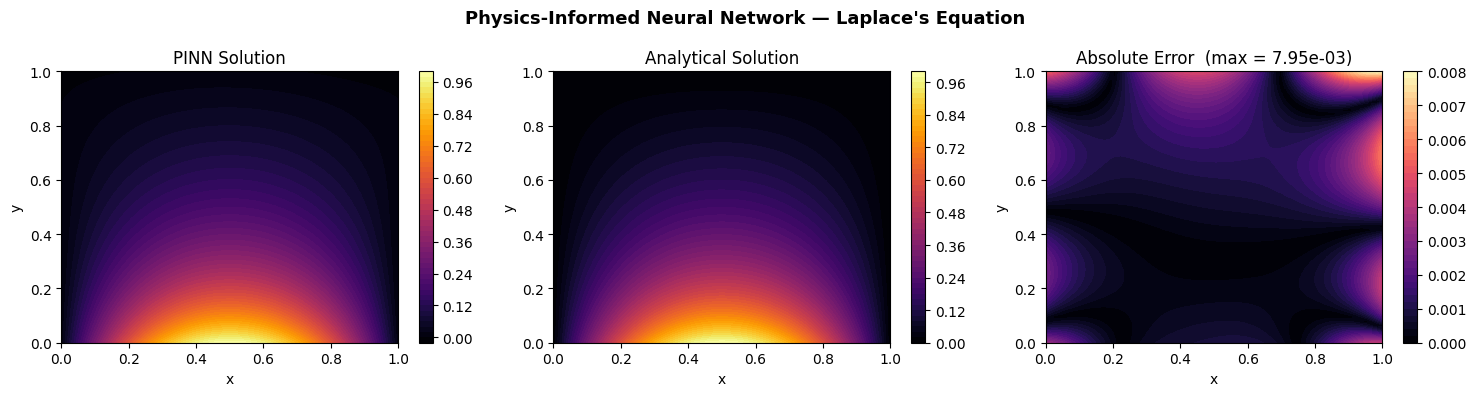

PINN — Max absolute error: 7.95e-03  |  Mean absolute error: 1.13e-03


In [8]:
# ----------------------------------------------------------
# Evaluate PINN on a dense grid
# ----------------------------------------------------------
model.eval()
N_eval = 64
x_eval = np.linspace(0, 1, N_eval)
y_eval = np.linspace(0, 1, N_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval)

x_t = torch.tensor(X_eval.ravel(), dtype=torch.float32).unsqueeze(1)
y_t = torch.tensor(Y_eval.ravel(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    U_pinn_flat = model(x_t, y_t).numpy().ravel()

U_pinn = U_pinn_flat.reshape(N_eval, N_eval)
U_exact_pinn = analytical_solution(X_eval, Y_eval)
pinn_error = np.abs(U_pinn - U_exact_pinn)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].contourf(X_eval, Y_eval, U_pinn, levels=50, cmap=CMAP)
axes[0].set_title("PINN Solution")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_eval, Y_eval, U_exact_pinn, levels=50, cmap=CMAP)
axes[1].set_title("Analytical Solution")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_eval, Y_eval, pinn_error, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error  (max = {pinn_error.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Physics-Informed Neural Network — Laplace's Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"PINN — Max absolute error: {pinn_error.max():.2e}  |  Mean absolute error: {pinn_error.mean():.2e}")

---

## Part 3 — Side-by-Side Comparison

We now place both solutions and both error maps next to each other for a direct visual comparison, and print a summary table.


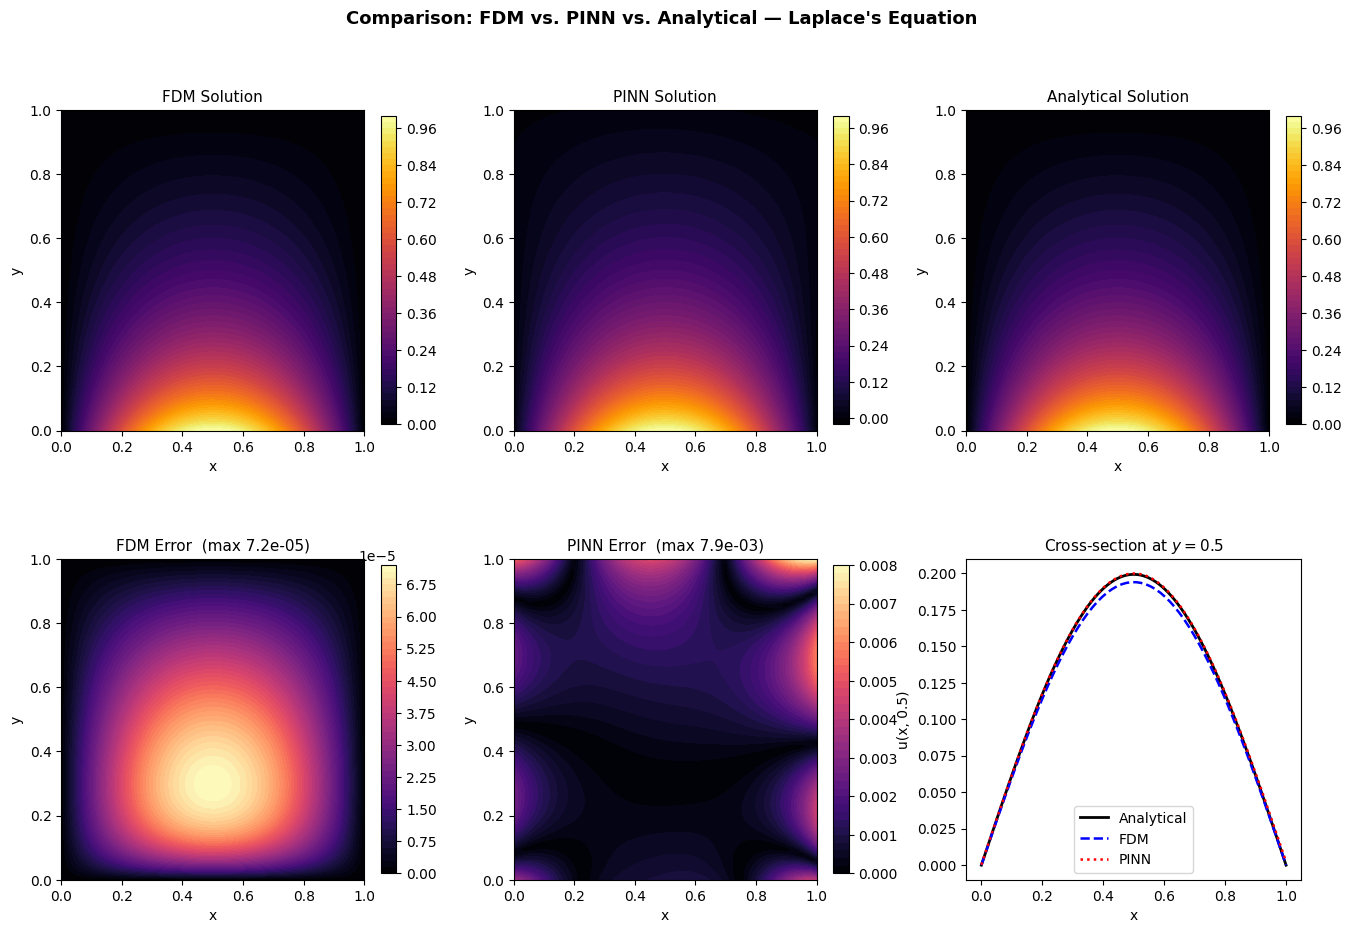

In [9]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

titles_row0 = ["FDM Solution", "PINN Solution", "Analytical Solution"]
solutions   = [U_fdm, U_pinn, U_exact_fdm]
grids       = [(X_fdm, Y_fdm), (X_eval, Y_eval), (X_fdm, Y_fdm)]

for col, (title, sol, (Xg, Yg)) in enumerate(zip(titles_row0, solutions, grids)):
    ax = fig.add_subplot(gs[0, col])
    cf = ax.contourf(Xg, Yg, sol, levels=50, cmap=CMAP)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(cf, ax=ax, fraction=0.046)

ax_fdm_err  = fig.add_subplot(gs[1, 0])
ax_pinn_err = fig.add_subplot(gs[1, 1])
ax_profile  = fig.add_subplot(gs[1, 2])

cf_e1 = ax_fdm_err.contourf(X_fdm, Y_fdm, fdm_error,  levels=50, cmap="magma")
ax_fdm_err.set_title(f"FDM Error  (max {fdm_error.max():.1e})", fontsize=11)
ax_fdm_err.set_xlabel("x"); ax_fdm_err.set_ylabel("y")
plt.colorbar(cf_e1, ax=ax_fdm_err, fraction=0.046)

cf_e2 = ax_pinn_err.contourf(X_eval, Y_eval, pinn_error, levels=50, cmap="magma")
ax_pinn_err.set_title(f"PINN Error  (max {pinn_error.max():.1e})", fontsize=11)
ax_pinn_err.set_xlabel("x"); ax_pinn_err.set_ylabel("y")
plt.colorbar(cf_e2, ax=ax_pinn_err, fraction=0.046)

# Cross-section at y = 0.5
x_line = np.linspace(0, 1, 200)
y_mid  = 0.5

# FDM cross-section (interpolate)
row_fdm  = int(round(y_mid * (N_FDM - 1)))
u_fdm_cs = U_fdm[row_fdm, :]
x_cs_fdm = X_fdm[row_fdm, :]

# PINN cross-section
x_t_cs = torch.tensor(x_line, dtype=torch.float32).unsqueeze(1)
y_t_cs = torch.full_like(x_t_cs, y_mid)
with torch.no_grad():
    u_pinn_cs = model(x_t_cs, y_t_cs).numpy().ravel()

# Analytical cross-section
u_exact_cs = np.sin(np.pi * x_line) * np.sinh(np.pi * (1 - y_mid)) / np.sinh(np.pi)

ax_profile.plot(x_line, u_exact_cs, "k-",  lw=2,   label="Analytical")
ax_profile.plot(x_cs_fdm, u_fdm_cs, "b--", lw=1.8, label="FDM")
ax_profile.plot(x_line, u_pinn_cs,  "r:",  lw=1.8, label="PINN")
ax_profile.set_title("Cross-section at $y = 0.5$", fontsize=11)
ax_profile.set_xlabel("x"); ax_profile.set_ylabel("u(x, 0.5)")
ax_profile.legend()

fig.suptitle("Comparison: FDM vs. PINN vs. Analytical — Laplace's Equation", fontsize=13, fontweight="bold")
plt.show()

In [10]:
print("=" * 55)
print(f"{'Method':<20} {'Max Error':>12} {'Mean Error':>12}")
print("-" * 55)
print(f"{'FDM':<20} {fdm_error.max():>12.2e} {fdm_error.mean():>12.2e}")
print(f"{'PINN':<20} {pinn_error.max():>12.2e} {pinn_error.mean():>12.2e}")
print("=" * 55)

Method                  Max Error   Mean Error
-------------------------------------------------------
FDM                      7.18e-05     2.71e-05
PINN                     7.95e-03     1.13e-03


---

## Summary

| Aspect | FDM | PINN |
|--------|-----|------|
| **Approach** | Discretize domain → solve $Au = b$ | Train a neural network | 
| **Requires mesh** | Yes — structured grid | No — meshfree |
| **Handles irregular geometry** | Difficult | Easy |
| **Accuracy** | $\mathcal{O}(h^2)$ for 2nd-order scheme | Depends on training; typically $10^{-3}$–$10^{-4}$ |
| **Computational cost** | Very fast (sparse linear algebra) | Slower — gradient back-propagation per iteration |
| **Scalability to high-D** | Poor ($N^d$ unknowns) | Better (curse of dimensionality less severe) |
| **Generalisation** | Solve once per problem setup | Can generalise across parameter families |

**When to use which:**
- Use **FDM** when geometry is simple, accuracy is critical, and speed matters.
- Use **PINNs** when the domain is complex, the PDE has variable/unknown parameters, or you need a differentiable surrogate model.
